3x3: [[ 1.  0.  0.]
 [ 0.  0.  1.]
 [ 0. -1.  0.]]
3x3: [[ 1.  0.  0.]
 [ 0.  0.  1.]
 [ 0. -1.  0.]]
3x3: [[ 1.  0.  0.]
 [ 0.  0.  1.]
 [ 0. -1.  0.]]
3x3: [[ 1.  0.  0.]
 [ 0.  0.  1.]
 [ 0. -1.  0.]]
3x3: [[-0.38268343  0.92387953  0.        ]
 [ 0.          0.          1.        ]
 [ 0.92387953  0.38268343 -0.        ]]
3x3: [[-0.38268343  0.92387953  0.        ]
 [ 0.          0.          1.        ]
 [ 0.92387953  0.38268343 -0.        ]]
3x3: [[-0.38268343 -0.92387953  0.        ]
 [ 0.          0.          1.        ]
 [-0.92387953  0.38268343  0.        ]]
3x3: [[-0.38268343 -0.92387953  0.        ]
 [ 0.          0.          1.        ]
 [-0.92387953  0.38268343  0.        ]]
3x3: [[-0.38268343  0.92387953  0.        ]
 [ 0.          0.          1.        ]
 [ 0.92387953  0.38268343 -0.        ]]
3x3: [[-0.38268343 -0.92387953  0.        ]
 [ 0.          0.          1.        ]
 [-0.92387953  0.38268343  0.        ]]
up_index: [ 6  7  8  9 10 11 12 13 14 15 16 17 19 20 21 22

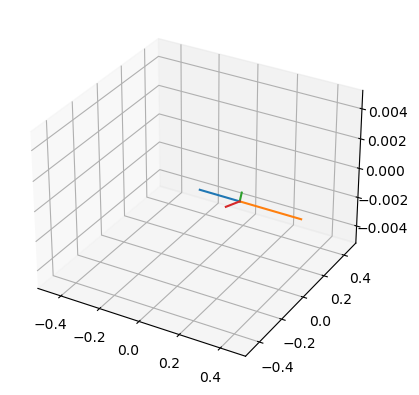

In [4]:
import math
import numpy as np
import matplotlib.pyplot as plt
from Scripts.drone import Drone
from Scripts.beams import BeamType
import Scripts.FEA_3D as FEA_3D

def plot_drone_geometry(drone,q):
    ax = plt.figure().add_subplot(projection='3d')
    ax.set_xlim([-0.5, 0.5])
    ax.set_ylim([-0.5, 0.5])
    ax.set_zlim([-0.005, 0.005])
    drone_geo = drone.beam_system
    node_loc = []
    for i in range(len(drone_geo.nodes)):
        node_loc.append(drone_geo.nodes[i].location)
    #ax.scatter(node_loc[:][0] + drone_geo.x_displacements,
    #           node_loc[:][1] + drone_geo.y_displacements, 
    #           node_loc[:][2] + drone_geo.z_displacements)
    
    for beam in drone_geo.beams:
        '''
        node_0_x = beam.start_node_coords[0]
        node_1_x = beam.end_node_coords[0]
        node_0_y = beam.start_node_coords[1]
        node_1_y = beam.end_node_coords[1]
        node_0_z = beam.start_node_coords[2]
        node_1_z = beam.end_node_coords[2]
        
        X_len = node_1_x - node_0_x
        Y_len = node_1_y - node_0_y
        Z_len = node_1_z - node_0_z

        X = np.empty(q)
        Y = np.empty(q)
        Z = np.empty(q)
        for i in range(q):
            N_X = FEA_3D.shape_function(X_len * i / q, X_len)
            N_Y = FEA_3D.shape_function(Y_len * i / q, Y_len)
            N_Z = FEA_3D.shape_function(Z_len * i / q, Z_len)
            X[i] = node_0_x + N_X[0] * beam.x_displacement[0] + N_X[1] * beam.x_angles[0] + N_X[2] * beam.x_displacement[1] + N_X[3] * beam.x_angles[1]
            Y[i] = node_0_y + N_Y[0] * beam.y_displacement[0] + N_Y[1] * beam.y_angles[0] +  N_Y[2] * beam.y_displacement[1] + N_Y[3] * beam.y_angles[1]
            Z[i] = node_0_z + N_Z[0] * beam.z_displacement[0] + N_Z[1] * beam.z_angles[0] + N_Z[2] * beam.z_displacement[1] + N_Z[3] * beam.z_angles[1]
        '''
        ax.plot([beam.start_node.location[0] + beam.x_displacements_global[0], beam.end_node.location[0] + beam.x_displacements_global[1]],
                [beam.start_node.location[1] + beam.y_displacements_global[0], beam.end_node.location[1] + beam.y_displacements_global[1]],
                [beam.start_node.location[2] + beam.z_displacements_global[0], beam.end_node.location[2] + beam.z_displacements_global[1]])


d1 = Drone("drone_test")
arm_beam = BeamType("annulus", [25, 20], "Aluminum7075-T6", "arm_beam")
strut_beam = BeamType("annulus", [30, 20], "Aluminum7075-T6", "strut_beam")

d1.create_drone_slice_nodes(0.5,0.2,8)           # nominal radius | strut rad | number of blades
# d1.rotate_drone_nodes(0,math.pi/5,math.pi/60)      # x-axis | y-axis | z-axis
d1.create_drone_slice_beams(arm_beam,strut_beam) # arm beam | strut beam

d1.beam_system.add_force(np.array([10,10,-1000]),"outer_node")

d1.boundary_conditions_slice()


#print(d1.beam_system.dp)
#print(np.shape(d1.beam_system.rp))
#print(np.shape(d1.beam_system.du))
#print(np.shape(d1.beam_system.dp))

d1.solve_fea()
#print(d1.beam_system.ru)
#print(d1.beam_system.rp)

#print(d1.beam_system.du)
#print(d1.beam_system.dp)

plot_drone_geometry(d1,10)

for node_num, node in enumerate(d1.beam_system.node_names):
    print(node + 
          " | x: " + str(d1.beam_system.x_displacements[node_num]) + 
          " | y: " + str(d1.beam_system.y_displacements[node_num]) +
          " | z: " + str(d1.beam_system.z_displacements[node_num]))

print(d1.beam_system.beams[0].return_shape_functions(0.5))

#print(d1.beam_system.force_moment_vector)
#print(d1.beam_system.displacement_angle_vector)
#print(d1.beam_system.node_names) good
#print(d1.beam_system.force_node_indexes) good
#print(d1.beam_system.ru)
#print(d1.beam_system.displacement_angle_vector)
#print(d1.beam_system.kup)
